<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/B%C3%80I_T%E1%BA%ACP_V%E1%BB%80_H%E1%BB%86_TH%E1%BB%90NG_T%C6%AF_V%E1%BA%A4N_User_based_Filltering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BÀI TẬP HỆ THỐNG TƯ VẤN
## PHẦN 1 — LỌC CỘNG TÁC THEO USER (User-based Collaborative Filtering)

**Học viên:** _(điền họ tên / MSHV)_  |  **Môn:** Trí tuệ nhân tạo nâng cao và ứng dụng

---

### Ma trận đánh giá (thang điểm 1–5)

| | Item 1 | Item 2 | Item 3 | Item 4 | Item 5 |
|---|---|---|---|---|---|
| **User A** | 5 | 3 | 4 | 4 | **?** |
| **User B** | 3 | 1 | 2 | 3 | 3 |
| **User C** | 4 | 3 | 4 | 3 | 5 |
| **User D** | 3 | 3 | 1 | 5 | 4 |
| **User E** | 1 | 5 | 5 | 2 | 1 |

Mục tiêu: dự đoán điểm User A sẽ cho **Item 5** bằng phương pháp lọc cộng tác theo người dùng.

### 0. Chuẩn bị dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# nan = chưa đánh giá (điểm cần dự đoán của User A cho Item 5)
data = {
    'Item1': [5, 3, 4, 3, 1],
    'Item2': [3, 1, 3, 3, 5],
    'Item3': [4, 2, 4, 1, 5],
    'Item4': [4, 3, 3, 5, 2],
    'Item5': [np.nan, 3, 5, 4, 1],
}
R = pd.DataFrame(data, index=['A', 'B', 'C', 'D', 'E'])
R

,Item1,Item2,Item3,Item4,Item5
A,5,3,4,4,NaN
B,3,1,2,3,3.0
C,4,3,4,3,5.0
D,3,3,1,5,4.0
E,1,5,5,2,1.0


## BÀI 1 — Độ tương đồng, láng giềng và dự đoán

### 1.1. Độ tương đồng Pearson giữa User A và các user còn lại

Hệ số tương quan Pearson được tính **trên các item cùng được đánh giá** (co-rated items). Với User A, các item chung là Item 1–4 (vì Item 5 chưa có điểm):

$$ sim(a,u)=\dfrac{\sum_{i\in I_{au}}(r_{a,i}-\bar r_a)(r_{u,i}-\bar r_u)}{\sqrt{\sum_{i\in I_{au}}(r_{a,i}-\bar r_a)^2}\;\sqrt{\sum_{i\in I_{au}}(r_{u,i}-\bar r_u)^2}} $$

trong đó $\bar r$ là trung bình điểm **trên các item chung**.

In [2]:
def pearson_corated(u, v):
    """Pearson trên các item mà CẢ HAI user cùng đánh giá."""
    u = np.asarray(u, float); v = np.asarray(v, float)
    mask = ~np.isnan(u) & ~np.isnan(v)
    u, v = u[mask], v[mask]
    if len(u) < 2:
        return 0.0
    um, vm = u.mean(), v.mean()
    num = np.sum((u - um) * (v - vm))
    den = np.sqrt(np.sum((u - um)**2)) * np.sqrt(np.sum((v - vm)**2))
    return num / den if den != 0 else 0.0

A = R.loc['A'].values
sims = {u: pearson_corated(A, R.loc[u].values) for u in ['B', 'C', 'D', 'E']}

print('Độ tương đồng Pearson giữa A và các user:')
for u, s in sims.items():
    print(f'  sim(A, {u}) = {s:+.4f}')

Độ tương đồng Pearson giữa A và các user:
  sim(A, B) = +0.8528
  sim(A, C) = +0.7071
  sim(A, D) = +0.0000
  sim(A, E) = -0.7921


**Nhận xét kết quả:**

| Cặp | sim | Ý nghĩa |
|---|---|---|
| A–B | **+0.853** | Rất giống nhau (cùng gu) |
| A–C | **+0.707** | Khá giống nhau |
| A–D | **0.000** | Không tương quan |
| A–E | **−0.792** | Ngược gu (gần như đối lập) |

### 1.2. Xác định 2 láng giềng gần nhất (K = 2)

Láng giềng = những user có **độ tương đồng dương cao nhất** với A.

In [3]:
order = sorted(sims, key=sims.get, reverse=True)   # sắp xếp giảm dần theo sim
print('Xếp hạng theo độ tương đồng:', [(u, round(sims[u], 3)) for u in order])

K = 2
neighbors = order[:K]
print(f'\n=> 2 láng giềng gần nhất của A (K={K}): {neighbors}')

Xếp hạng theo độ tương đồng: [('B', np.float64(0.853)), ('C', np.float64(0.707)), ('D', np.float64(0.0)), ('E', np.float64(-0.792))]

=> 2 láng giềng gần nhất của A (K=2): ['B', 'C']


**Kết luận:** 2 láng giềng gần nhất của A là **User B (0.853)** và **User C (0.707)**.

### 1.3. Dự đoán điểm của User A cho Item 5 — công thức mean-centered (Resnick)

$$ \hat r_{a,i}= \bar r_a + \dfrac{\sum_{u\in N}sim(a,u)\,(r_{u,i}-\bar r_u)}{\sum_{u\in N}|sim(a,u)|} $$

với $\bar r$ là **trung bình điểm trên toàn bộ item mà user đó đã đánh giá**. Công thức trừ đi trung bình của mỗi user để khử **thiên lệch (bias)** giữa người khó tính và người dễ tính.

In [4]:
mean_all = R.mean(axis=1, skipna=True)   # trung bình trên toàn bộ item đã đánh giá
print('Trung bình từng user:')
print(mean_all.round(3).to_string())

def predict_centered(neighbors):
    ra = mean_all['A']
    num = sum(sims[u] * (R.loc[u, 'Item5'] - mean_all[u]) for u in neighbors)
    den = sum(abs(sims[u]) for u in neighbors)
    return ra + num / den if den != 0 else ra

pred_c = predict_centered(neighbors)
print(f'\nDự đoán (mean-centered, K=2): r(A, Item5) = {pred_c:.4f}  ~ {pred_c:.2f}')

Trung bình từng user:
A    4.0
B    2.4
C    3.8
D    3.2
E    2.8

Dự đoán (mean-centered, K=2): r(A, Item5) = 4.8720  ~ 4.87


**Diễn giải phép tính (K=2, láng giềng B và C):**

- $\bar r_A = 4.0,\; \bar r_B = 2.4,\; \bar r_C = 3.8$
- Độ lệch của láng giềng ở Item 5: $r_{B,5}-\bar r_B = 3-2.4 = 0.6$;  $r_{C,5}-\bar r_C = 5-3.8 = 1.2$
- Tử số $= 0.853(0.6) + 0.707(1.2) = 1.360$
- Mẫu số $= 0.853 + 0.707 = 1.560$
- $\hat r_{A,5} = 4.0 + \dfrac{1.360}{1.560} = 4.0 + 0.872 = \mathbf{4.87}$

Cả B và C đều cho Item 5 điểm **cao hơn mức trung bình của họ**, nên mô hình dự đoán A cũng sẽ cho Item 5 điểm cao hơn mức trung bình 4.0 của A → **≈ 4.87 (làm tròn 5)**.

### 1.4. So sánh với công thức trung bình có trọng số (không khử trung bình)

$$ \hat r_{a,i}=\dfrac{\sum_{u\in N}sim(a,u)\,r_{u,i}}{\sum_{u\in N}|sim(a,u)|} $$

In [5]:
def predict_weighted(neighbors):
    num = sum(sims[u] * R.loc[u, 'Item5'] for u in neighbors)
    den = sum(abs(sims[u]) for u in neighbors)
    return num / den if den != 0 else np.nan

pred_w = predict_weighted(neighbors)
print(f'Dự đoán (trung bình có trọng số, K=2): {pred_w:.4f} ~ {pred_w:.2f}')
print(f'Dự đoán (mean-centered,            K=2): {pred_c:.4f} ~ {pred_c:.2f}')
print(f'Chênh lệch: {pred_c - pred_w:.2f}')

Dự đoán (trung bình có trọng số, K=2): 3.9066 ~ 3.91
Dự đoán (mean-centered,            K=2): 4.8720 ~ 4.87
Chênh lệch: 0.97


**Giải thích sự khác biệt (4.87 so với 3.91):**

- Công thức **trung bình có trọng số** dùng trực tiếp điểm thô của láng giềng, nên kết quả ≈ trung bình điểm Item 5 của B và C (3 và 5) → **≈ 3.91**.
- Công thức **mean-centered** trước hết trừ đi mức trung bình của mỗi user. User A vốn chấm cao (trung bình 4.0), còn B là người khó tính (trung bình 2.4). Việc cộng lại $\bar r_A = 4.0$ và cộng phần *độ lệch dương* của láng giềng làm kết quả cao hơn → **≈ 4.87**.
- **Kết luận:** mean-centered **chính xác hơn** vì khử được thiên lệch thang điểm giữa các user (người dễ tính / khó tính). Đây là lý do công thức Resnick được dùng phổ biến trong thực tế.

## BÀI 2 — Phân tích ảnh hưởng của tham số K

### 2.1. Tính lại dự đoán khi K thay đổi từ 1 đến 4

In [6]:
rows = []
for k in range(1, 5):
    nb = order[:k]
    p = predict_centered(nb)
    p_clip = min(max(p, 1), 5)      # giới hạn trong thang 1..5
    rows.append({'K': k, 'Láng giềng': ', '.join(nb),
                 'Dự đoán': round(p, 3), 'Sau khi giới hạn [1,5]': round(p_clip, 3)})

df_k = pd.DataFrame(rows)
df_k

,K,Láng giềng,Dự đoán,"Sau khi giới hạn [1,5]"
0,1,B,4.600,4.600
1,2,"B, C",4.872,4.872
2,3,"B, C, D",4.872,4.872
3,4,"B, C, D, E",5.185,5.000


### 2.2. Biểu đồ quan hệ giữa K và giá trị dự đoán

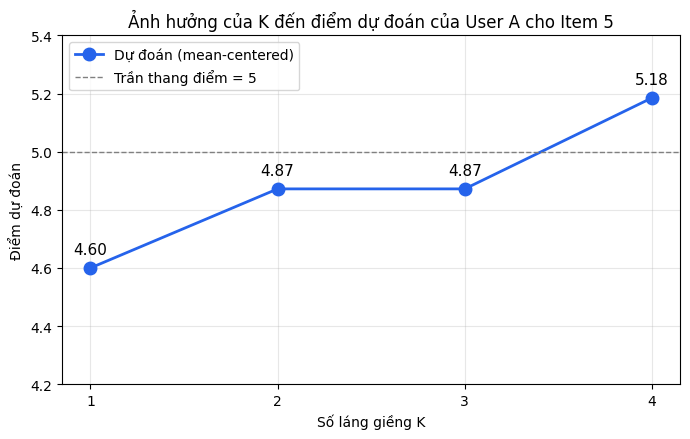

In [7]:
plt.figure(figsize=(7, 4.5))
plt.plot(df_k['K'], df_k['Dự đoán'], 'o-', color='#2563eb', linewidth=2,
         markersize=9, label='Dự đoán (mean-centered)')
plt.axhline(5, color='gray', linestyle='--', linewidth=1, label='Trần thang điểm = 5')
for _, r in df_k.iterrows():
    plt.annotate(f"{r['Dự đoán']:.2f}", (r['K'], r['Dự đoán']),
                 textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
plt.title('Ảnh hưởng của K đến điểm dự đoán của User A cho Item 5', fontsize=12)
plt.xlabel('Số láng giềng K'); plt.ylabel('Điểm dự đoán')
plt.xticks([1, 2, 3, 4]); plt.ylim(4.2, 5.4)
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()

### 2.3. Phân tích: giá trị K nào tốt nhất? Tại sao?

| K | Láng giềng thêm vào | sim | Dự đoán |
|---|---|---|---|
| 1 | B | +0.853 | 4.60 |
| 2 | + C | +0.707 | **4.87** |
| 3 | + D | 0.000 | 4.87 |
| 4 | + E | −0.792 | 5.19 → 5.00 |

- **K = 1:** chỉ dựa vào một người (B) → dễ bị nhiễu, thiếu ổn định.
- **K = 2:** thêm C (tương đồng cao) → dự đoán **ổn định, đáng tin cậy nhất**.
- **K = 3:** thêm D có sim = 0 → **không đóng góp gì**, kết quả không đổi.
- **K = 4:** thêm E có sim **âm** (−0.79, ngược gu) → kéo dự đoán vượt trần thang điểm (5.19), buộc phải cắt về 5.0 → **gây méo kết quả**.

**K = 2 cho kết quả tốt nhất**: đủ láng giềng để ổn định nhưng chỉ gồm các user thực sự tương đồng cao. Nguyên tắc thực hành: **chỉ chọn láng giềng có độ tương đồng dương và cao**, loại bỏ user có sim ≤ 0.

### 2.4. Ưu và nhược điểm khi chọn K nhỏ so với K lớn

| | **K nhỏ** (vd K=1) | **K lớn** (vd K=4) |
|---|---|---|
| **Ưu điểm** | Tính nhanh; chỉ dùng người tương đồng nhất; kết quả rõ ràng | Kết quả ổn định, ít nhiễu; giảm ảnh hưởng của 1 đánh giá lệch |
| **Nhược điểm** | Nhạy nhiễu; phụ thuộc 1 người; dễ sai nếu láng giềng đó bất thường | Kéo thêm user ít/không tương đồng, thậm chí sim âm → **méo dự đoán**; chậm hơn |

**Kết luận chung:** cần chọn K **vừa phải** (thường 2–3 với dữ liệu nhỏ này), và **chỉ giữ láng giềng có độ tương đồng dương đủ lớn**. K quá nhỏ → thiếu ổn định; K quá lớn → nhiễu do đưa vào các user không liên quan hoặc ngược gu.